In [1]:
import pandas as pd
import numpy as np
import subprocess
import matplotlib.pyplot as plt

data_dir      = "/home/qmoreau/gogo_bursts/stats_new"
clinical_xlsx = "/home/qmoreau/gogo_bursts/stat_output/Clinical_Motor_data_for_analysis_For_Poster_With_GRVP_ZScores.xlsx"
pc            = 8
epoch         = "RESP"
outlier_sd    = 3

df_burst = pd.read_csv(f"{data_dir}/PC_{pc}_{epoch}_trial_burst_counts.csv")
df_burst['subject_id'] = df_burst['subject_id'].astype(str)

df_demo = pd.read_excel(clinical_xlsx).rename(columns=str.lower)
df_demo = df_demo.rename(columns={'study_id': 'subject_id'})[['subject_id', 'age']]
df_demo['subject_id'] = df_demo['subject_id'].astype(str)

df_burst = df_burst.merge(df_demo, on='subject_id', how='left')
df_burst = df_burst[df_burst['response_time'].notna() & df_burst['age'].notna()]

def remove_rt_outliers(df, rt_col, sd_thresh=outlier_sd):
    g = df.groupby('subject_id')[rt_col]
    mean, sd = g.transform('mean'), g.transform('std')
    return df[(df[rt_col] - mean).abs() <= sd_thresh * sd]

time_cols = [c for c in df_burst.columns if c.startswith('time_')]
time_vals = np.array([float(c.split('_', 1)[1]) for c in time_cols])
print(f"{len(time_cols)} time columns, {time_vals.min():.3f} to {time_vals.max():.3f} s")

window_width = 0.2
step_size    = 0.1
XLIM         = (-0.5, 1.5)


113 time columns, -1.400 to 1.400 s



Tertile 1
1204 LONG→SHORT pairs, 33 subjects
Outliers removed: 25 / 1204
Done: 54 rows

Stderr: Loading required package: Matrix

8 / 54 window-term rows p < .05


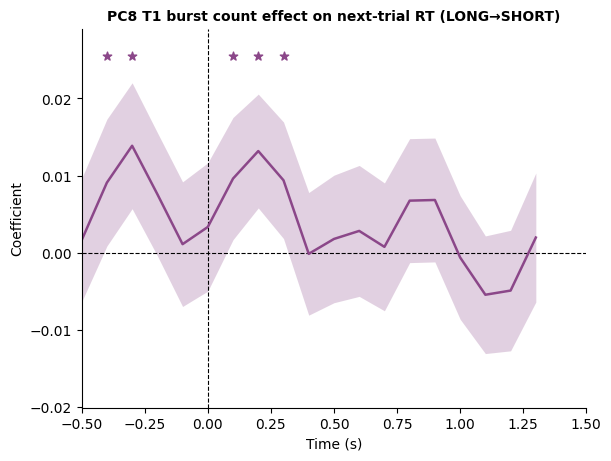

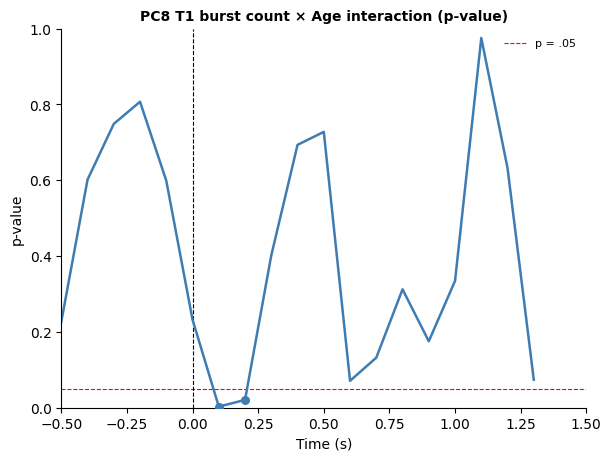

In [2]:
# ── Tertile 1 ─────────────────────────────────────────────────────────
tert = 1
print(f"\n{'='*60}\nTertile {tert}\n{'='*60}")

df_t = df_burst[df_burst['tertile'] == tert]

# long-short pairing
df_short = df_t[df_t['condition'] == 'SHORT'][['subject_id', 'trial_idx', 'response_time']].copy()
df_short['trial_idx'] = df_short['trial_idx'] - 1
df_short = df_short.rename(columns={'response_time': 'next_rt'})

df_pairs = df_t[df_t['condition'] == 'LONG'].merge(
    df_short, on=['subject_id', 'trial_idx'], how='inner'
)
print(f"{len(df_pairs)} LONG→SHORT pairs, {df_pairs['subject_id'].nunique()} subjects")

before = len(df_pairs)
df_pairs = remove_rt_outliers(df_pairs, 'next_rt')
print(f"Outliers removed: {before - len(df_pairs)} / {before}")

df_pairs['age_c']       = (df_pairs['age'] - df_pairs['age'].mean()) / df_pairs['age'].std()
df_pairs['trial_idx_s'] = (df_pairs['trial_idx'] - df_pairs['trial_idx'].mean()) / df_pairs['trial_idx'].std()

# ── SLIDING WINDOW, Gamma GLMM ─────────────────────────────
df_pairs[['subject_id', 'next_rt', 'age_c', 'trial_idx_s'] + time_cols].to_csv(
    f'./tmp_gogo_pc{pc}_t{tert}_sliding.csv', index=False)

r_script = f"""
library(lme4)

df_base <- read.csv('./tmp_gogo_pc{pc}_t{tert}_sliding.csv', check.names = FALSE)
df_base$subject_id <- as.character(df_base$subject_id)

window_width <- {window_width}
step_size    <- {step_size}
time_cols    <- grep("^time_", colnames(df_base), value = TRUE)
time_vals    <- as.numeric(gsub("time_", "", time_cols))
t_min <- min(time_vals, na.rm = TRUE)
t_max <- max(time_vals, na.rm = TRUE)
time_centers <- seq(t_min + window_width/2, t_max - window_width/2, by = step_size)

fit_glmm_safe <- function(formula, data) {{
  tryCatch(
    withCallingHandlers(
      glmer(formula, data = data, family = Gamma(link = "log"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))),
      warning = function(w) invokeRestart("muffleWarning")
    ),
    error = function(e) NULL
  )
}}

all_results <- data.frame()

for (t_c in time_centers) {{
  win_cols <- time_cols[time_vals >= t_c - window_width/2 & time_vals <= t_c + window_width/2]
  if (length(win_cols) == 0) next

  temp <- df_base[, c('next_rt', 'age_c', 'trial_idx_s', 'subject_id')]
  if (length(win_cols) == 1) {{
    temp$burst_count <- df_base[[win_cols[1]]]
  }} else {{
    temp$burst_count <- rowMeans(as.matrix(df_base[, win_cols]), na.rm = TRUE)
  }}

  model <- fit_glmm_safe(next_rt ~ burst_count * age_c + trial_idx_s + (1 | subject_id), temp)
  if (is.null(model)) next

  coefs <- summary(model)$coefficients
  for (term in c('burst_count', 'burst_count:age_c')) {{
    if (term %in% rownames(coefs)) {{
      all_results <- rbind(all_results, data.frame(
        time_s    = t_c,
        term      = term,
        estimate  = coefs[term, "Estimate"],
        std_error = coefs[term, "Std. Error"],
        p_value   = coefs[term, "Pr(>|z|)"]
      ))
    }}
  }}
}}

write.csv(all_results, './gogo_pc{pc}_t{tert}_LONGtoSHORT_gamma_windows.csv', row.names = FALSE)
cat(sprintf("Done: %d rows\\n", nrow(all_results)))
"""

with open(f'./tmp_gogo_pc{pc}_t{tert}_sliding.R', 'w') as f:
    f.write(r_script)

result = subprocess.run(['Rscript', f'./tmp_gogo_pc{pc}_t{tert}_sliding.R'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Stderr:", result.stderr)

df_results = pd.read_csv(f'./gogo_pc{pc}_t{tert}_LONGtoSHORT_gamma_windows.csv')
df_results.to_csv(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_windows.csv", index=False)
print(f"{(df_results['p_value'] < 0.05).sum()} / {len(df_results)} window-term rows p < .05")

# ── PLOT: BURST COUNT MAIN EFFECT ───────────────────────────
color_main = '#8B4789'

d = df_results[df_results['term'] == 'burst_count'].sort_values('time_s')
d = d[(d['time_s'] >= XLIM[0]) & (d['time_s'] <= XLIM[1])]

y_min = (d['estimate'] - 1.96 * d['std_error']).min()
y_max = (d['estimate'] + 1.96 * d['std_error']).max()
y_pad = 0.2 * (y_max - y_min)
star_y = y_max + 0.5 * y_pad

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.fill_between(d['time_s'], d['estimate'] - 1.96*d['std_error'], d['estimate'] + 1.96*d['std_error'],
                 color=color_main, alpha=0.25, linewidth=0)
ax.plot(d['time_s'], d['estimate'], color=color_main, linewidth=1.8, label='Burst count')
sig = d[d['p_value'] < 0.05]
ax.scatter(sig['time_s'], [star_y] * len(sig), color=color_main, s=40, marker='*', zorder=3)
ax.set_xlim(XLIM)
ax.set_ylim(y_min - y_pad, y_max + y_pad)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Coefficient')
ax.set_title(f'PC{pc} T{tert} burst count effect on next-trial RT (LONG→SHORT)', fontweight='bold', fontsize=10)

fig.savefig(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_main_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()

# ── PLOT: BURST COUNT × AGE INTERACTION (P-VALUES) ──────────
color_int = '#3E7CB1'

d_p = df_results[df_results['term'] == 'burst_count:age_c'].sort_values('time_s')
d_p = d_p[(d_p['time_s'] >= XLIM[0]) & (d_p['time_s'] <= XLIM[1])]

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.axhline(0.05, color='r', linestyle='--', linewidth=0.8, label='p = .05')
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.plot(d_p['time_s'], d_p['p_value'], color=color_int, linewidth=1.8)
sig = d_p[d_p['p_value'] < 0.05]
ax.scatter(sig['time_s'], sig['p_value'], color=color_int, s=30, zorder=3)
ax.set_xlim(XLIM)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (s)')
ax.set_ylabel('p-value')
ax.set_title(f'PC{pc} T{tert} burst count × Age interaction (p-value)', fontweight='bold', fontsize=10)
ax.legend(fontsize=8, frameon=False)

fig.savefig(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_interaction_p_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()



Tertile 2
1204 LONG→SHORT pairs, 33 subjects
Outliers removed: 25 / 1204
Done: 54 rows

Stderr: Loading required package: Matrix

3 / 54 window-term rows p < .05


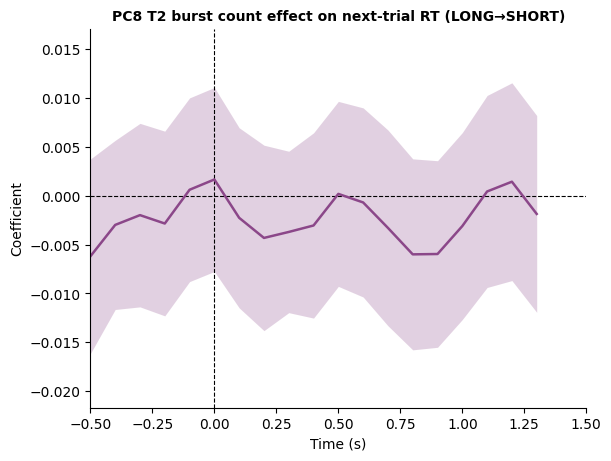

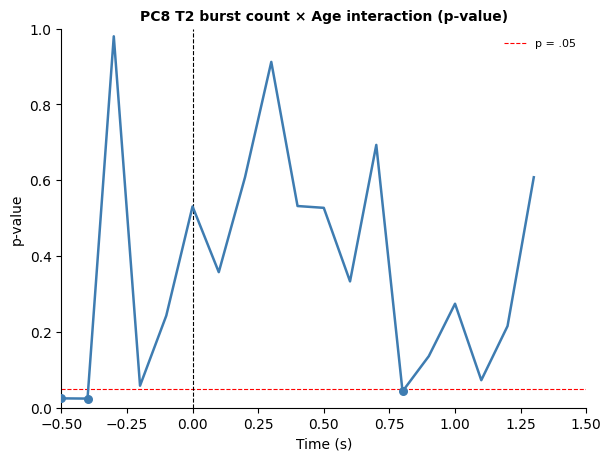

In [3]:
# ── Tertile 2 ─────────────────────────────────────────────────────────
tert = 2
print(f"\n{'='*60}\nTertile {tert}\n{'='*60}")

df_t = df_burst[df_burst['tertile'] == tert]

# long-short pairing
df_short = df_t[df_t['condition'] == 'SHORT'][['subject_id', 'trial_idx', 'response_time']].copy()
df_short['trial_idx'] = df_short['trial_idx'] - 1
df_short = df_short.rename(columns={'response_time': 'next_rt'})

df_pairs = df_t[df_t['condition'] == 'LONG'].merge(
    df_short, on=['subject_id', 'trial_idx'], how='inner'
)
print(f"{len(df_pairs)} LONG→SHORT pairs, {df_pairs['subject_id'].nunique()} subjects")

before = len(df_pairs)
df_pairs = remove_rt_outliers(df_pairs, 'next_rt')
print(f"Outliers removed: {before - len(df_pairs)} / {before}")

df_pairs['age_c']       = (df_pairs['age'] - df_pairs['age'].mean()) / df_pairs['age'].std()
df_pairs['trial_idx_s'] = (df_pairs['trial_idx'] - df_pairs['trial_idx'].mean()) / df_pairs['trial_idx'].std()

# ── SLIDING WINDOW, Gamma GLMM ─────────────────────────────
df_pairs[['subject_id', 'next_rt', 'age_c', 'trial_idx_s'] + time_cols].to_csv(
    f'./tmp_gogo_pc{pc}_t{tert}_sliding.csv', index=False)

r_script = f"""
library(lme4)

df_base <- read.csv('./tmp_gogo_pc{pc}_t{tert}_sliding.csv', check.names = FALSE)
df_base$subject_id <- as.character(df_base$subject_id)

window_width <- {window_width}
step_size    <- {step_size}
time_cols    <- grep("^time_", colnames(df_base), value = TRUE)
time_vals    <- as.numeric(gsub("time_", "", time_cols))
t_min <- min(time_vals, na.rm = TRUE)
t_max <- max(time_vals, na.rm = TRUE)
time_centers <- seq(t_min + window_width/2, t_max - window_width/2, by = step_size)

fit_glmm_safe <- function(formula, data) {{
  tryCatch(
    withCallingHandlers(
      glmer(formula, data = data, family = Gamma(link = "log"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))),
      warning = function(w) invokeRestart("muffleWarning")
    ),
    error = function(e) NULL
  )
}}

all_results <- data.frame()

for (t_c in time_centers) {{
  win_cols <- time_cols[time_vals >= t_c - window_width/2 & time_vals <= t_c + window_width/2]
  if (length(win_cols) == 0) next

  temp <- df_base[, c('next_rt', 'age_c', 'trial_idx_s', 'subject_id')]
  if (length(win_cols) == 1) {{
    temp$burst_count <- df_base[[win_cols[1]]]
  }} else {{
    temp$burst_count <- rowMeans(as.matrix(df_base[, win_cols]), na.rm = TRUE)
  }}

  model <- fit_glmm_safe(next_rt ~ burst_count * age_c + trial_idx_s + (1 | subject_id), temp)
  if (is.null(model)) next

  coefs <- summary(model)$coefficients
  for (term in c('burst_count', 'burst_count:age_c')) {{
    if (term %in% rownames(coefs)) {{
      all_results <- rbind(all_results, data.frame(
        time_s    = t_c,
        term      = term,
        estimate  = coefs[term, "Estimate"],
        std_error = coefs[term, "Std. Error"],
        p_value   = coefs[term, "Pr(>|z|)"]
      ))
    }}
  }}
}}

write.csv(all_results, './gogo_pc{pc}_t{tert}_LONGtoSHORT_gamma_windows.csv', row.names = FALSE)
cat(sprintf("Done: %d rows\\n", nrow(all_results)))
"""

with open(f'./tmp_gogo_pc{pc}_t{tert}_sliding.R', 'w') as f:
    f.write(r_script)

result = subprocess.run(['Rscript', f'./tmp_gogo_pc{pc}_t{tert}_sliding.R'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Stderr:", result.stderr)

df_results = pd.read_csv(f'./gogo_pc{pc}_t{tert}_LONGtoSHORT_gamma_windows.csv')
df_results.to_csv(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_windows.csv", index=False)
print(f"{(df_results['p_value'] < 0.05).sum()} / {len(df_results)} window-term rows p < .05")

# ── PLOT: BURST COUNT MAIN EFFECT ───────────────────────────
color_main = '#8B4789'

d = df_results[df_results['term'] == 'burst_count'].sort_values('time_s')
d = d[(d['time_s'] >= XLIM[0]) & (d['time_s'] <= XLIM[1])]

y_min = (d['estimate'] - 1.96 * d['std_error']).min()
y_max = (d['estimate'] + 1.96 * d['std_error']).max()
y_pad = 0.2 * (y_max - y_min)
star_y = y_max + 0.5 * y_pad

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.fill_between(d['time_s'], d['estimate'] - 1.96*d['std_error'], d['estimate'] + 1.96*d['std_error'],
                 color=color_main, alpha=0.25, linewidth=0)
ax.plot(d['time_s'], d['estimate'], color=color_main, linewidth=1.8, label='Burst count')
sig = d[d['p_value'] < 0.05]
ax.scatter(sig['time_s'], [star_y] * len(sig), color=color_main, s=40, marker='*', zorder=3)
ax.set_xlim(XLIM)
ax.set_ylim(y_min - y_pad, y_max + y_pad)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Coefficient')
ax.set_title(f'PC{pc} T{tert} burst count effect on next-trial RT (LONG→SHORT)', fontweight='bold', fontsize=10)

fig.savefig(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_main_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()

# ── PLOT: BURST COUNT × AGE INTERACTION (P-VALUES) ──────────
color_int = '#3E7CB1'

d_p = df_results[df_results['term'] == 'burst_count:age_c'].sort_values('time_s')
d_p = d_p[(d_p['time_s'] >= XLIM[0]) & (d_p['time_s'] <= XLIM[1])]

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.axhline(0.05, color='r', linestyle='--', linewidth=0.8, label='p = .05')
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.plot(d_p['time_s'], d_p['p_value'], color=color_int, linewidth=1.8)
sig = d_p[d_p['p_value'] < 0.05]
ax.scatter(sig['time_s'], sig['p_value'], color=color_int, s=30, zorder=3)
ax.set_xlim(XLIM)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (s)')
ax.set_ylabel('p-value')
ax.set_title(f'PC{pc} T{tert} burst count × Age interaction (p-value)', fontweight='bold', fontsize=10)
ax.legend(fontsize=8, frameon=False)

fig.savefig(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_interaction_p_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()



Tertile 3
1204 LONG→SHORT pairs, 33 subjects
Outliers removed: 25 / 1204
Done: 54 rows

Stderr: Loading required package: Matrix

7 / 54 window-term rows p < .05


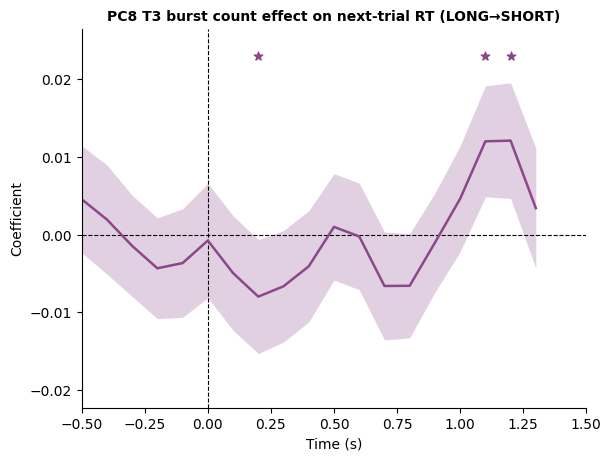

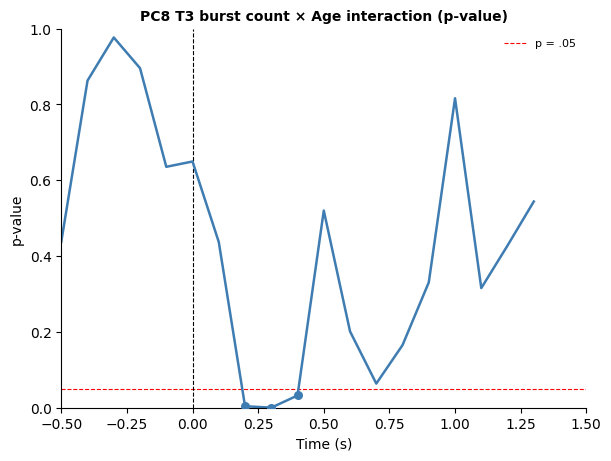

In [4]:
# ── Tertile 3 ─────────────────────────────────────────────────────────
tert = 3
print(f"\n{'='*60}\nTertile {tert}\n{'='*60}")

df_t = df_burst[df_burst['tertile'] == tert]

# long-short pairing
df_short = df_t[df_t['condition'] == 'SHORT'][['subject_id', 'trial_idx', 'response_time']].copy()
df_short['trial_idx'] = df_short['trial_idx'] - 1
df_short = df_short.rename(columns={'response_time': 'next_rt'})

df_pairs = df_t[df_t['condition'] == 'LONG'].merge(
    df_short, on=['subject_id', 'trial_idx'], how='inner'
)
print(f"{len(df_pairs)} LONG→SHORT pairs, {df_pairs['subject_id'].nunique()} subjects")

before = len(df_pairs)
df_pairs = remove_rt_outliers(df_pairs, 'next_rt')
print(f"Outliers removed: {before - len(df_pairs)} / {before}")

df_pairs['age_c']       = (df_pairs['age'] - df_pairs['age'].mean()) / df_pairs['age'].std()
df_pairs['trial_idx_s'] = (df_pairs['trial_idx'] - df_pairs['trial_idx'].mean()) / df_pairs['trial_idx'].std()

# ── SLIDING WINDOW, Gamma GLMM ─────────────────────────────
df_pairs[['subject_id', 'next_rt', 'age_c', 'trial_idx_s'] + time_cols].to_csv(
    f'./tmp_gogo_pc{pc}_t{tert}_sliding.csv', index=False)

r_script = f"""
library(lme4)

df_base <- read.csv('./tmp_gogo_pc{pc}_t{tert}_sliding.csv', check.names = FALSE)
df_base$subject_id <- as.character(df_base$subject_id)

window_width <- {window_width}
step_size    <- {step_size}
time_cols    <- grep("^time_", colnames(df_base), value = TRUE)
time_vals    <- as.numeric(gsub("time_", "", time_cols))
t_min <- min(time_vals, na.rm = TRUE)
t_max <- max(time_vals, na.rm = TRUE)
time_centers <- seq(t_min + window_width/2, t_max - window_width/2, by = step_size)

fit_glmm_safe <- function(formula, data) {{
  tryCatch(
    withCallingHandlers(
      glmer(formula, data = data, family = Gamma(link = "log"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))),
      warning = function(w) invokeRestart("muffleWarning")
    ),
    error = function(e) NULL
  )
}}

all_results <- data.frame()

for (t_c in time_centers) {{
  win_cols <- time_cols[time_vals >= t_c - window_width/2 & time_vals <= t_c + window_width/2]
  if (length(win_cols) == 0) next

  temp <- df_base[, c('next_rt', 'age_c', 'trial_idx_s', 'subject_id')]
  if (length(win_cols) == 1) {{
    temp$burst_count <- df_base[[win_cols[1]]]
  }} else {{
    temp$burst_count <- rowMeans(as.matrix(df_base[, win_cols]), na.rm = TRUE)
  }}

  model <- fit_glmm_safe(next_rt ~ burst_count * age_c + trial_idx_s + (1 | subject_id), temp)
  if (is.null(model)) next

  coefs <- summary(model)$coefficients
  for (term in c('burst_count', 'burst_count:age_c')) {{
    if (term %in% rownames(coefs)) {{
      all_results <- rbind(all_results, data.frame(
        time_s    = t_c,
        term      = term,
        estimate  = coefs[term, "Estimate"],
        std_error = coefs[term, "Std. Error"],
        p_value   = coefs[term, "Pr(>|z|)"]
      ))
    }}
  }}
}}

write.csv(all_results, './gogo_pc{pc}_t{tert}_LONGtoSHORT_gamma_windows.csv', row.names = FALSE)
cat(sprintf("Done: %d rows\\n", nrow(all_results)))
"""

with open(f'./tmp_gogo_pc{pc}_t{tert}_sliding.R', 'w') as f:
    f.write(r_script)

result = subprocess.run(['Rscript', f'./tmp_gogo_pc{pc}_t{tert}_sliding.R'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Stderr:", result.stderr)

df_results = pd.read_csv(f'./gogo_pc{pc}_t{tert}_LONGtoSHORT_gamma_windows.csv')
df_results.to_csv(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_windows.csv", index=False)
print(f"{(df_results['p_value'] < 0.05).sum()} / {len(df_results)} window-term rows p < .05")

# ── PLOT: BURST COUNT MAIN EFFECT ───────────────────────────
color_main = '#8B4789'

d = df_results[df_results['term'] == 'burst_count'].sort_values('time_s')
d = d[(d['time_s'] >= XLIM[0]) & (d['time_s'] <= XLIM[1])]

y_min = (d['estimate'] - 1.96 * d['std_error']).min()
y_max = (d['estimate'] + 1.96 * d['std_error']).max()
y_pad = 0.2 * (y_max - y_min)
star_y = y_max + 0.5 * y_pad

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.fill_between(d['time_s'], d['estimate'] - 1.96*d['std_error'], d['estimate'] + 1.96*d['std_error'],
                 color=color_main, alpha=0.25, linewidth=0)
ax.plot(d['time_s'], d['estimate'], color=color_main, linewidth=1.8, label='Burst count')
sig = d[d['p_value'] < 0.05]
ax.scatter(sig['time_s'], [star_y] * len(sig), color=color_main, s=40, marker='*', zorder=3)
ax.set_xlim(XLIM)
ax.set_ylim(y_min - y_pad, y_max + y_pad)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Coefficient')
ax.set_title(f'PC{pc} T{tert} burst count effect on next-trial RT (LONG→SHORT)', fontweight='bold', fontsize=10)

fig.savefig(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_main_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()

# ── PLOT: BURST COUNT × AGE INTERACTION (P-VALUES) ──────────
color_int = '#3E7CB1'

d_p = df_results[df_results['term'] == 'burst_count:age_c'].sort_values('time_s')
d_p = d_p[(d_p['time_s'] >= XLIM[0]) & (d_p['time_s'] <= XLIM[1])]

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
ax.axhline(0.05, color='r', linestyle='--', linewidth=0.8, label='p = .05')
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.plot(d_p['time_s'], d_p['p_value'], color=color_int, linewidth=1.8)
sig = d_p[d_p['p_value'] < 0.05]
ax.scatter(sig['time_s'], sig['p_value'], color=color_int, s=30, zorder=3)
ax.set_xlim(XLIM)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Time (s)')
ax.set_ylabel('p-value')
ax.set_title(f'PC{pc} T{tert} burst count × Age interaction (p-value)', fontweight='bold', fontsize=10)
ax.legend(fontsize=8, frameon=False)

fig.savefig(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_interaction_p_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()


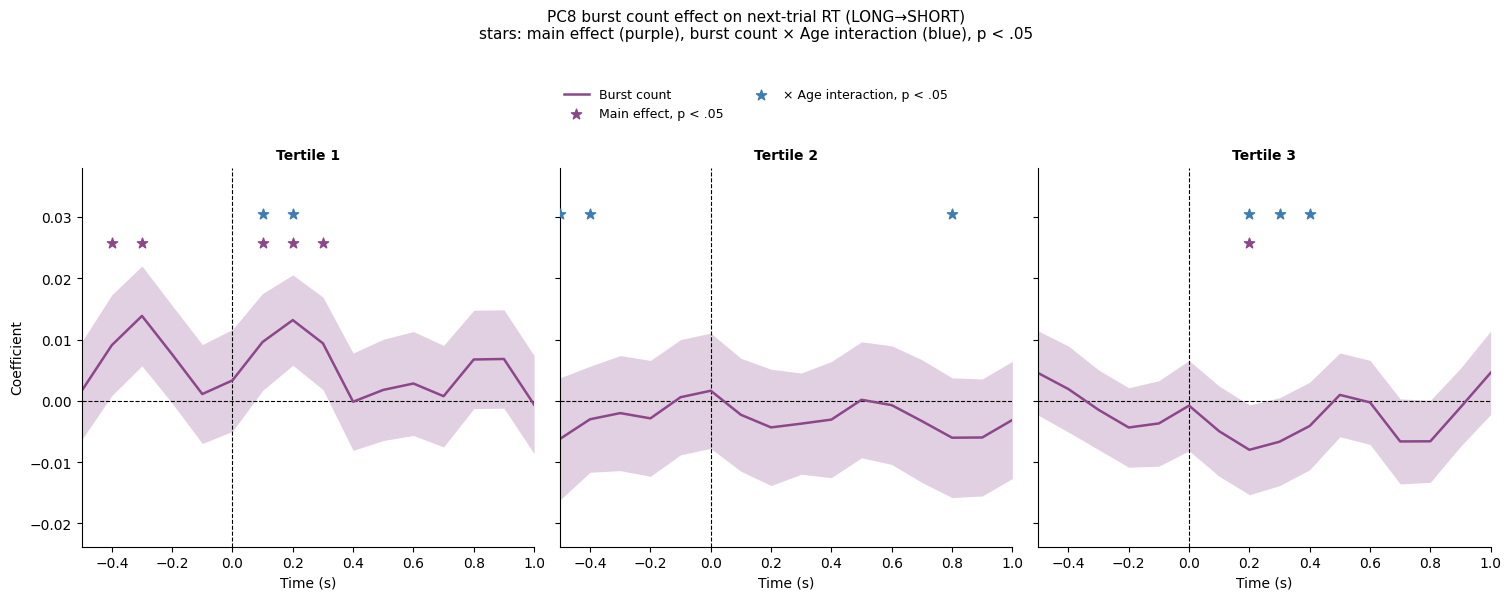

In [7]:
# ── COMBINED: all three tertiles, main effect ± main-effect and Age-interaction significance ──
color_main = '#8B4789'
color_int  = '#3E7CB1'
XLIM_PLOT  = (-0.5, 1.0)

tertile_data = {}
all_estimates_lo, all_estimates_hi = [], []

for tert in [1, 2, 3]:
    df_results = pd.read_csv(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_windows.csv")

    d = df_results[df_results['term'] == 'burst_count'].sort_values('time_s')
    d = d[(d['time_s'] >= XLIM_PLOT[0]) & (d['time_s'] <= XLIM_PLOT[1])]

    d_int = df_results[df_results['term'] == 'burst_count:age_c'].sort_values('time_s')
    d_int = d_int[(d_int['time_s'] >= XLIM_PLOT[0]) & (d_int['time_s'] <= XLIM_PLOT[1])]

    tertile_data[tert] = (d, d_int)
    all_estimates_lo.append((d['estimate'] - 1.96 * d['std_error']).min())
    all_estimates_hi.append((d['estimate'] + 1.96 * d['std_error']).max())

y_min       = min(all_estimates_lo)
y_max       = max(all_estimates_hi)
y_pad       = 0.2 * (y_max - y_min)
star_y_main = y_max + 0.5 * y_pad
star_y_int  = y_max + 1.1 * y_pad

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True)

for ax, tert in zip(axes, [1, 2, 3]):
    d, d_int = tertile_data[tert]

    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.fill_between(d['time_s'], d['estimate'] - 1.96*d['std_error'], d['estimate'] + 1.96*d['std_error'],
                     color=color_main, alpha=0.25, linewidth=0)
    ax.plot(d['time_s'], d['estimate'], color=color_main, linewidth=1.8, label='Burst count')

    sig_main = d[d['p_value'] < 0.05]
    ax.scatter(sig_main['time_s'], [star_y_main] * len(sig_main), color=color_main, s=60, marker='*', zorder=3,
               label='Main effect, p < .05')

    sig_int = d_int[d_int['p_value'] < 0.05]
    ax.scatter(sig_int['time_s'], [star_y_int] * len(sig_int), color=color_int, s=60, marker='*', zorder=3,
               label='× Age interaction, p < .05')

    ax.set_xlim(XLIM_PLOT)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Tertile {tert}', fontweight='bold', fontsize=10)

axes[0].set_ylabel('Coefficient')
axes[0].set_ylim(y_min - y_pad, star_y_int + y_pad)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.15))
fig.suptitle(f'PC{pc} burst count effect on next-trial RT (LONG→SHORT)\n'
             f'stars: main effect (purple), burst count × Age interaction (blue), p < .05',
             fontsize=11, y=1.3)

fig.savefig(f"{data_dir}/PC_{pc}_{epoch}_LONGtoSHORT_combined_tertiles_plot.pdf", bbox_inches='tight', dpi=150)
plt.show()

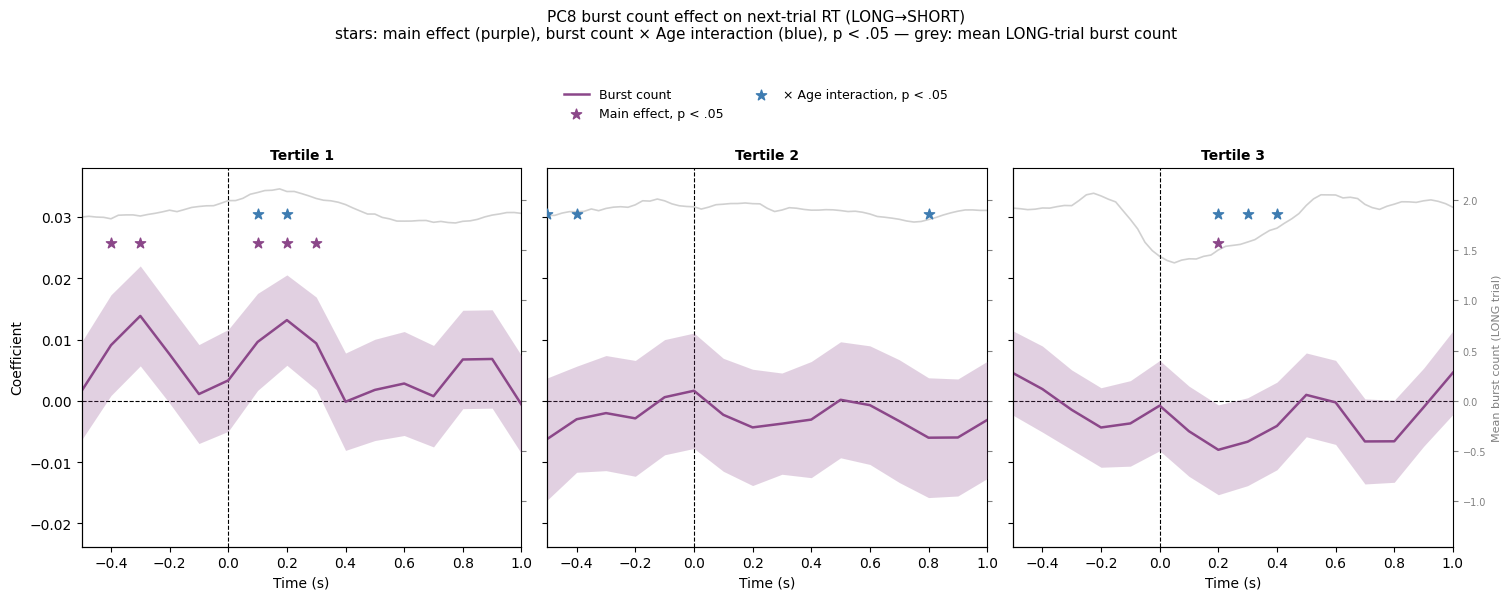

In [8]:
# ── COMBINED: all three tertiles, main effect + significance, LONG-trial burst rate behind ──
color_main = '#8B4789'
color_int  = '#3E7CB1'
color_rate = '0.4'
XLIM_PLOT  = (-0.5, 1.0)

tertile_data = {}
all_estimates_lo, all_estimates_hi = [], []
rate_curves = {}
all_rate_lo, all_rate_hi = [], []

for tert in [1, 2, 3]:
    df_results = pd.read_csv(f"{data_dir}/PC_{pc}_T{tert}_{epoch}_LONGtoSHORT_windows.csv")

    d = df_results[df_results['term'] == 'burst_count'].sort_values('time_s')
    d = d[(d['time_s'] >= XLIM_PLOT[0]) & (d['time_s'] <= XLIM_PLOT[1])]

    d_int = df_results[df_results['term'] == 'burst_count:age_c'].sort_values('time_s')
    d_int = d_int[(d_int['time_s'] >= XLIM_PLOT[0]) & (d_int['time_s'] <= XLIM_PLOT[1])]

    tertile_data[tert] = (d, d_int)
    all_estimates_lo.append((d['estimate'] - 1.96 * d['std_error']).min())
    all_estimates_hi.append((d['estimate'] + 1.96 * d['std_error']).max())

    # burst rate behind: mean burst count from the LONG trials that feed the model for this tertile
    df_t      = df_burst[df_burst['tertile'] == tert]
    df_long_t = df_t[df_t['condition'] == 'LONG']
    rate_vals = df_long_t[time_cols].mean(axis=0).values
    rate_curves[tert] = (time_vals, rate_vals)

    mask = (time_vals >= XLIM_PLOT[0]) & (time_vals <= XLIM_PLOT[1])
    all_rate_lo.append(rate_vals[mask].min())
    all_rate_hi.append(rate_vals[mask].max())

y_min       = min(all_estimates_lo)
y_max       = max(all_estimates_hi)
y_pad       = 0.2 * (y_max - y_min)
star_y_main = y_max + 0.5 * y_pad
star_y_int  = y_max + 1.1 * y_pad
ax_lo, ax_hi = y_min - y_pad, star_y_int + y_pad

rate_min = min(all_rate_lo)
rate_max = max(all_rate_hi)

# align the rate axis' zero with the coefficient axis' zero, same trick as the PC12 overlay
f_zero = -ax_lo / (ax_hi - ax_lo)
k = max(-rate_min / f_zero, rate_max / (1 - f_zero)) * 1.1
rate_ylim = (-k * f_zero, k * (1 - f_zero))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True)

for ax, tert in zip(axes, [1, 2, 3]):
    d, d_int = tertile_data[tert]

    ax_rate = ax.twinx()
    ax_rate.set_zorder(ax.get_zorder() - 1)
    ax.patch.set_visible(False)

    t_vals, r_vals = rate_curves[tert]
    ax_rate.plot(t_vals, r_vals, color=color_rate, alpha=0.3, linewidth=1.2, zorder=0)
    ax_rate.set_ylim(rate_ylim)
    ax_rate.set_xlim(XLIM_PLOT)
    ax_rate.tick_params(axis="y", labelsize=7, colors="0.5")
    if tert == 3:
        ax_rate.set_ylabel("Mean burst count (LONG trial)", fontsize=8, color="0.5")
    else:
        ax_rate.set_yticklabels([])

    ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=1)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, zorder=1)
    ax.fill_between(d['time_s'], d['estimate'] - 1.96*d['std_error'], d['estimate'] + 1.96*d['std_error'],
                     color=color_main, alpha=0.25, linewidth=0, zorder=2)
    ax.plot(d['time_s'], d['estimate'], color=color_main, linewidth=1.8, label='Burst count', zorder=2)

    sig_main = d[d['p_value'] < 0.05]
    ax.scatter(sig_main['time_s'], [star_y_main] * len(sig_main), color=color_main, s=60, marker='*', zorder=3,
               label='Main effect, p < .05')

    sig_int = d_int[d_int['p_value'] < 0.05]
    ax.scatter(sig_int['time_s'], [star_y_int] * len(sig_int), color=color_int, s=60, marker='*', zorder=3,
               label='× Age interaction, p < .05')

    ax.set_xlim(XLIM_PLOT)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Tertile {tert}', fontweight='bold', fontsize=10)

axes[0].set_ylabel('Coefficient')
axes[0].set_ylim(ax_lo, ax_hi)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.15))
fig.suptitle(f'PC{pc} burst count effect on next-trial RT (LONG→SHORT)\n'
             f'stars: main effect (purple), burst count × Age interaction (blue), p < .05 — grey: mean LONG-trial burst count',
             fontsize=11, y=1.3)

plt.show()